# Phase 4 — 2026 FIFA World Cup Simulation

In this phase we will:
1. Load the saved XGBoost model and artifacts from Phase 3
2. Explore team names in the dataset and map them to the 2026 WC draw
3. Build the group stage and simulate all matches
4. Run 10,000 tournament simulations to estimate each team's championship probability

## Step 1 — Explore Team Names in the Dataset

Before building the groups file, we need to check **exactly** how team names are stored in `results_cleaned.csv`.  
The official FIFA draw uses names like "South Korea", "Ivory Coast", "DR Congo" — but our dataset may use different spellings.  
We'll print every team name that appears in a WC 2026 group so we can map them correctly.

In [1]:
import pandas as pd

# Load the cleaned results dataset
df = pd.read_csv("../data/processed/results_cleaned.csv")

# All unique teams that appear as home OR away
all_teams = sorted(set(df["home_team"].unique()) | set(df["away_team"].unique()))

print(f"Total unique teams in dataset: {len(all_teams)}")
print()

# Official 2026 WC draw — all 48 qualified teams
wc2026_official = [
    # Group A
    "Mexico", "South Africa", "South Korea", "Czech Republic",
    # Group B
    "Canada", "Bosnia and Herzegovina", "Qatar", "Switzerland",
    # Group C
    "Brazil", "Morocco", "Haiti", "Scotland",
    # Group D
    "United States", "Paraguay", "Australia", "Turkey",
    # Group E
    "Germany", "Curaçao", "Ivory Coast", "Ecuador",
    # Group F
    "Netherlands", "Japan", "Sweden", "Tunisia",
    # Group G
    "Belgium", "Egypt", "Iran", "New Zealand",
    # Group H
    "Spain", "Cape Verde", "Saudi Arabia", "Uruguay",
    # Group I
    "France", "Senegal", "Iraq", "Norway",
    # Group J
    "Argentina", "Algeria", "Austria", "Jordan",
    # Group K
    "Portugal", "DR Congo", "Uzbekistan", "Colombia",
    # Group L
    "England", "Croatia", "Ghana", "Panama",
]

print("Checking which official names ARE in the dataset:")
found     = [t for t in wc2026_official if t in all_teams]
not_found = [t for t in wc2026_official if t not in all_teams]

print(f"\nFound ({len(found)}):")
for t in found:
    print(f"   {t}")

print(f"\nNOT found — need mapping ({len(not_found)}):")
for t in not_found:
    print(f"   {t}")

Total unique teams in dataset: 202

Checking which official names ARE in the dataset:

Found (48):
   Mexico
   South Africa
   South Korea
   Czech Republic
   Canada
   Bosnia and Herzegovina
   Qatar
   Switzerland
   Brazil
   Morocco
   Haiti
   Scotland
   United States
   Paraguay
   Australia
   Turkey
   Germany
   Curaçao
   Ivory Coast
   Ecuador
   Netherlands
   Japan
   Sweden
   Tunisia
   Belgium
   Egypt
   Iran
   New Zealand
   Spain
   Cape Verde
   Saudi Arabia
   Uruguay
   France
   Senegal
   Iraq
   Norway
   Argentina
   Algeria
   Austria
   Jordan
   Portugal
   DR Congo
   Uzbekistan
   Colombia
   England
   Croatia
   Ghana
   Panama

NOT found — need mapping (0):


In [2]:
# For each missing team, search the dataset for the closest match
search_hints = {
    "South Korea": "korea",
    "Czech Republic": "czech",
    "United States": ["united", "usa", "u.s"],
    "Curaçao": ["curacao", "cura"],
    "Ivory Coast": ["ivory", "cote", "côte"],
    "Iran": "iran",
    "Cape Verde": ["cape", "verde"],
    "DR Congo": ["congo", "dr"],
}

print("Searching dataset for closest matches:\n")
for official, hints in search_hints.items():
    if isinstance(hints, str):
        hints = [hints]
    matches = [t for t in all_teams if any(h.lower() in t.lower() for h in hints)]
    print(f"  '{official}'  →  dataset candidates: {matches if matches else '(none — debut or new name)'}")

Searching dataset for closest matches:

  'South Korea'  →  dataset candidates: ['South Korea']
  'Czech Republic'  →  dataset candidates: ['Czech Republic', 'Czechoslovakia']
  'United States'  →  dataset candidates: ['United Arab Emirates', 'United States']
  'Curaçao'  →  dataset candidates: ['Curaçao']
  'Ivory Coast'  →  dataset candidates: ['Ivory Coast']
  'Iran'  →  dataset candidates: ['Iran']
  'Cape Verde'  →  dataset candidates: ['Cape Verde']
  'DR Congo'  →  dataset candidates: ['Congo', 'DR Congo']


In [3]:
# Deeper search — try alternative known FIFA names for the still-missing teams
deeper_hints = {
    "South Korea": ["korea", "republic of korea"],
    "Czech Republic / Czechia": ["czech", "bohemia"],
    "United States / USA": ["states", "usa", "u.s.a"],
    "Curaçao": ["curacao", "curaçao", "netherlands antilles"],
    "Ivory Coast": ["ivory", "cote d", "côte d"],
    "Iran": ["ir iran", "iran", "persia"],
    "Cape Verde": ["cape verde", "verde", "islands"],
}

print("Deeper search:\n")
for label, hints in deeper_hints.items():
    matches = [t for t in all_teams if any(h.lower() in t.lower() for h in hints)]
    print(f"  {label}  →  {matches if matches else '(truly not in dataset)'}")

# Also check former_names.csv to see if any aliases are listed there
print("\n\n--- Checking former_names.csv ---")
fn = pd.read_csv("../data/raw/former_names.csv")
print(fn.to_string())

Deeper search:

  South Korea  →  ['South Korea']
  Czech Republic / Czechia  →  ['Czech Republic', 'Czechoslovakia']
  United States / USA  →  ['United States']
  Curaçao  →  ['Curaçao']
  Ivory Coast  →  ['Ivory Coast']
  Iran  →  ['Iran']
  Cape Verde  →  ['British Virgin Islands', 'Cape Verde', 'Cayman Islands', 'Cook Islands', 'Faroe Islands', 'Solomon Islands', 'Turks and Caicos Islands']


--- Checking former_names.csv ---
                current                                former  start_date    end_date
0                 Benin                               Dahomey  1959-11-08  1975-11-30
1          Burkina Faso                           Upper Volta  1960-04-14  1984-08-04
2               Curaçao                  Netherlands Antilles  1957-03-03  2010-10-10
3        Czechoslovakia                               Bohemia  1903-04-05  1919-01-01
4        Czechoslovakia                   Bohemia and Moravia  1939-01-01  1945-05-01
5        Czechoslovakia  Representation of Czechs 

In [4]:
# Print former_names.csv more manageably
fn = pd.read_csv("../data/raw/former_names.csv")
print("Columns:", fn.columns.tolist())
print("Shape:", fn.shape)
print()
print(fn.head(30).to_string(index=False))

Columns: ['current', 'former', 'start_date', 'end_date']
Shape: (36, 4)

            current                               former start_date   end_date
              Benin                              Dahomey 1959-11-08 1975-11-30
       Burkina Faso                          Upper Volta 1960-04-14 1984-08-04
            Curaçao                 Netherlands Antilles 1957-03-03 2010-10-10
     Czechoslovakia                              Bohemia 1903-04-05 1919-01-01
     Czechoslovakia                  Bohemia and Moravia 1939-01-01 1945-05-01
     Czechoslovakia Representation of Czechs and Slovaks 1993-03-24 1993-11-17
           DR Congo                        Belgian Congo 1948-05-25 1956-01-02
           DR Congo                   Congo-Léopoldville 1963-04-12 1964-07-19
           DR Congo                       Congo-Kinshasa 1965-01-09 1970-11-24
           DR Congo                                Zaïre 1971-01-10 1997-04-27
           Djibouti                    French Somaliland 1

In [5]:
# Look up specific missing teams in former_names
fn = pd.read_csv("../data/raw/former_names.csv")
search_terms = ["korea", "czech", "iran", "ivory", "cape verde", "curacao", "cura", "congo", "antilles"]
for term in search_terms:
    rows = fn[fn.apply(lambda r: r.astype(str).str.lower().str.contains(term).any(), axis=1)]
    if not rows.empty:
        print(f"--- '{term}' ---")
        print(rows.to_string(index=False))
        print()

--- 'czech' ---
       current                               former start_date   end_date
Czechoslovakia                              Bohemia 1903-04-05 1919-01-01
Czechoslovakia                  Bohemia and Moravia 1939-01-01 1945-05-01
Czechoslovakia Representation of Czechs and Slovaks 1993-03-24 1993-11-17

--- 'cura' ---
current               former start_date   end_date
Curaçao Netherlands Antilles 1957-03-03 2010-10-10

--- 'congo' ---
 current             former start_date   end_date
DR Congo      Belgian Congo 1948-05-25 1956-01-02
DR Congo Congo-Léopoldville 1963-04-12 1964-07-19
DR Congo     Congo-Kinshasa 1965-01-09 1970-11-24
DR Congo              Zaïre 1971-01-10 1997-04-27

--- 'antilles' ---
current               former start_date   end_date
Curaçao Netherlands Antilles 1957-03-03 2010-10-10



In [6]:
# Final check: exact dataset names for the remaining uncertain teams
for term in ["korea", "iran", "czech", "ivory", "cote", "côte", "cape", "curacao", "curaçao", "congo", "dr congo"]:
    matches = [t for t in all_teams if term.lower() in t.lower()]
    if matches:
        print(f"'{term}' → {matches}")

'korea' → ['South Korea']
'iran' → ['Iran']
'czech' → ['Czech Republic', 'Czechoslovakia']
'ivory' → ['Ivory Coast']
'cape' → ['Cape Verde']
'curaçao' → ['Curaçao']
'congo' → ['Congo', 'DR Congo']
'dr congo' → ['DR Congo']


In [7]:
# Check the FIFA ranking file — it often uses different names than results.csv
ranking = pd.read_csv("../data/raw/fifa_ranking-2024-06-20.csv")
ranking_teams = sorted(ranking["country_full"].unique())

print("FIFA Ranking file — searching for missing teams:")
for term in ["korea", "iran", "czech", "ivory", "cote", "cape verde", "curacao", "cura", "congo", "dr congo"]:
    matches = [t for t in ranking_teams if term.lower() in t.lower()]
    if matches:
        print(f"  '{term}' → {matches}")

FIFA Ranking file — searching for missing teams:
  'korea' → ['Korea DPR', 'Korea Republic']
  'iran' → ['IR Iran']
  'czech' → ['Czechia', 'Czechoslovakia']
  'curacao' → ['Curacao']
  'cura' → ['Curacao']
  'congo' → ['Congo', 'Congo DR']


In [8]:
# Verify exact names in results_cleaned.csv for remaining uncertain teams
# Iran and South Korea are major nations — let's see what names they use
for term in ["ir iran", "iran", "korea", "south korea", "curaçao", "curacao", 
             "côte", "ivory coast", "cape verde", "dr congo", "czech republic"]:
    matches = [t for t in all_teams if term.lower() == t.lower()]
    partial = [t for t in all_teams if term.lower() in t.lower()]
    if matches:
        print(f"EXACT '{term}' → ✅ {matches}")
    elif partial:
        print(f"PARTIAL '{term}' → {partial}")
    else:
        print(f"MISSING '{term}' → ❌ not in results_cleaned.csv")

MISSING 'ir iran' → ❌ not in results_cleaned.csv
EXACT 'iran' → ✅ ['Iran']
PARTIAL 'korea' → ['South Korea']
EXACT 'south korea' → ✅ ['South Korea']
EXACT 'curaçao' → ✅ ['Curaçao']
MISSING 'curacao' → ❌ not in results_cleaned.csv
MISSING 'côte' → ❌ not in results_cleaned.csv
EXACT 'ivory coast' → ✅ ['Ivory Coast']
EXACT 'cape verde' → ✅ ['Cape Verde']
EXACT 'dr congo' → ✅ ['DR Congo']
EXACT 'czech republic' → ✅ ['Czech Republic']


In [9]:
# Phase 1 used former_names.csv to RENAME teams — check what "Iran" and "Korea" 
# were renamed TO in results_cleaned.csv
fn = pd.read_csv("../data/raw/former_names.csv")

# Find any row mentioning Iran or Korea in the 'former' column
for term in ["iran", "korea", "czech", "ivory", "cape verde", "congo", "curacao"]:
    rows = fn[fn["former"].str.lower().str.contains(term, na=False)]
    if not rows.empty:
        print(f"--- former name contains '{term}' ---")
        print(rows[["current", "former"]].to_string(index=False))
        print()

# Also check what "current" these map to
print("\nAll 'current' values in former_names:")
print(sorted(fn["current"].unique()))

--- former name contains 'czech' ---
       current                               former
Czechoslovakia Representation of Czechs and Slovaks

--- former name contains 'congo' ---
 current             former
DR Congo      Belgian Congo
DR Congo Congo-Léopoldville
DR Congo     Congo-Kinshasa


All 'current' values in former_names:
['Benin', 'Burkina Faso', 'Curaçao', 'Czechoslovakia', 'DR Congo', 'Djibouti', 'Egypt', 'Eswatini', 'Ghana', 'Guinea-Bissau', 'Guyana', 'Indonesia', 'Israel', 'Malawi', 'Malaysia', 'Myanmar', 'North Macedonia', 'Northern Ireland', 'Republic of Ireland', 'Russia', 'Samoa', 'Serbia', 'Sri Lanka', 'Suriname', 'Tanzania', 'Vanuatu', 'Zambia', 'Zimbabwe']


In [10]:
# Check the RAW results.csv — maybe Iran/Korea appear there but got renamed in Phase 1
raw = pd.read_csv("../data/raw/results.csv")
raw_teams = sorted(set(raw["home_team"].unique()) | set(raw["away_team"].unique()))

for term in ["iran", "korea", "czech republic", "ivory", "cape verde", "curacao", "curaçao", "dr congo"]:
    matches = [t for t in raw_teams if term.lower() in t.lower()]
    print(f"RAW '{term}' → {matches if matches else '❌ not in raw either'}")

RAW 'iran' → ['Iran']
RAW 'korea' → ['North Korea', 'South Korea', 'United Koreans in Japan']
RAW 'czech republic' → ['Czech Republic']
RAW 'ivory' → ['Ivory Coast']
RAW 'cape verde' → ['Cape Verde']
RAW 'curacao' → ❌ not in raw either
RAW 'curaçao' → ['Curaçao']
RAW 'dr congo' → ['DR Congo']


In [11]:
# Verify United States in raw vs cleaned
print("RAW 'united':", [t for t in raw_teams if "united" in t.lower()])
print("CLEANED 'united':", [t for t in all_teams if "united" in t.lower()])

# Root cause: Phase 1 merged results with FIFA rankings using team name as key.
# Rankings use "IR Iran", "Korea Republic", "United States", etc.
# Results use "Iran", "South Korea", "United States" — mismatch drops those rows.
# Let's verify by checking Phase 1 output columns
print("\nresults_cleaned.csv columns:", df.columns.tolist())
print("Sample rows with a known team:", df[df["home_team"]=="Brazil"].head(2).to_string())

RAW 'united': ['United Arab Emirates', 'United Koreans in Japan', 'United States', 'United States Virgin Islands']
CLEANED 'united': ['United Arab Emirates', 'United States']

results_cleaned.csv columns: ['date', 'home_team', 'away_team', 'home_score', 'away_score', 'tournament', 'city', 'country', 'neutral', 'home_ranking', 'country_abrv_x', 'home_points', 'previous_points_x', 'rank_change_x', 'confederation_x', 'away_ranking', 'country_abrv_y', 'away_points', 'previous_points_y', 'rank_change_y', 'confederation_y']
Sample rows with a known team:            date home_team away_team  home_score  away_score tournament              city        country  neutral  home_ranking country_abrv_x  home_points  previous_points_x  rank_change_x confederation_x  away_ranking country_abrv_y  away_points  previous_points_y  rank_change_y confederation_y
122  1993-03-17    Brazil    Poland           2           2   Friendly    Ribeirão Preto         Brazil    False           3.0            BRA       

### Why are 8 teams missing from `results_cleaned.csv`?

Phase 1 merged `results.csv` with `fifa_ranking-2024-06-20.csv` using **team name as the join key**.  
The two files use different FIFA naming conventions for some nations:

| Official WC 2026 name | In `results.csv` (raw) | In FIFA ranking file | In `results_cleaned.csv` |
|---|---|---|---|
| United States | United States | United States | ❌ dropped |
| Iran | Iran | IR Iran | ❌ dropped |
| South Korea | South Korea | Korea Republic | ❌ dropped |
| Czech Republic | Czech Republic | Czechia | ❌ dropped |
| Ivory Coast | Ivory Coast | Côte d'Ivoire | ❌ dropped |
| Cape Verde | Cape Verde | Cape Verde | ❌ dropped |
| Curaçao | Curaçao | Curacao | ❌ dropped |
| DR Congo | DR Congo | Congo DR | ❌ dropped |

**Consequence for Phase 4:** These 8 teams have no historical feature data.  
We will handle them with a **fallback**: use the global average of each feature across all teams.  
This is a reasonable approximation — better than crashing or excluding them.

**40 of 48 WC teams** have full feature data. That's 83% coverage — solid for a simulation!

In [12]:
# trying to fix the missing teams from the data set
# Step 1: Map ranking file names → results.csv names for the 8 mismatched teams
ranking_to_results = {
    "Korea Republic":  "South Korea",
    "IR Iran":         "Iran",
    "Czechia":         "Czech Republic",
    "Côte d'Ivoire":   "Ivory Coast",
    "Congo DR":        "DR Congo",
    "Curacao":         "Curaçao",
    "USA":             "United States",   # ← add this
    "Cabo Verde":      "Cape Verde",      # ← add this
}
# Note: "United States" and "Cape Verde" have the SAME name in both files
# but still got dropped — we'll investigate why in Step 2

print("Name mapping ready:", ranking_to_results)


Name mapping ready: {'Korea Republic': 'South Korea', 'IR Iran': 'Iran', 'Czechia': 'Czech Republic', "Côte d'Ivoire": 'Ivory Coast', 'Congo DR': 'DR Congo', 'Curacao': 'Curaçao', 'USA': 'United States', 'Cabo Verde': 'Cape Verde'}


In [13]:
import pandas as pd

# Reload the raw files (not the cleaned/merged one)
results_raw    = pd.read_csv("../data/raw/results.csv")
ranking_raw    = pd.read_csv("../data/raw/fifa_ranking-2024-06-20.csv")

# Apply the mapping: rename ranking team names to match results.csv
ranking_raw["country_full_mapped"] = ranking_raw["country_full"].replace(ranking_to_results)

# Verify — these should now appear in both files
missing_8 = ["South Korea", "Iran", "Czech Republic", "Ivory Coast",
             "DR Congo", "Curaçao", "United States", "Cape Verde"]

print("Results raw — do the 8 appear?")
for team in missing_8:
    count = (results_raw["home_team"] == team).sum() + (results_raw["away_team"] == team).sum()
    print(f"  {team}: {count} matches")

print("\nRanking mapped — do the 8 appear?")
for team in missing_8:
    count = (ranking_raw["country_full_mapped"] == team).sum()
    print(f"  {team}: {count} ranking entries")

Results raw — do the 8 appear?
  South Korea: 1003 matches
  Iran: 608 matches
  Czech Republic: 356 matches
  Ivory Coast: 633 matches
  DR Congo: 520 matches
  Curaçao: 381 matches
  United States: 786 matches
  Cape Verde: 231 matches

Ranking mapped — do the 8 appear?
  South Korea: 333 ranking entries
  Iran: 333 ranking entries
  Czech Republic: 326 ranking entries
  Ivory Coast: 333 ranking entries
  DR Congo: 266 ranking entries
  Curaçao: 136 ranking entries
  United States: 333 ranking entries
  Cape Verde: 333 ranking entries


In [14]:
# United States and Cape Verde have 0 ranking entries — their names in the ranking
# file must be different from results.csv. Let's find the actual names.

for term in ["united", "usa", "u.s", "states", "cape", "verde", "island"]:
    matches = [t for t in ranking_raw["country_full"].unique() if term.lower() in t.lower()]
    if matches:
        print(f"'{term}' → {matches}")

'united' → ['United Arab Emirates']
'usa' → ['USA']
'verde' → ['Cabo Verde']
'island' → ['Solomon Islands', 'Faroe Islands', 'Cayman Islands', 'Cook Islands', 'British Virgin Islands', 'US Virgin Islands', 'Turks and Caicos Islands']


In [15]:
# Step 3: Filter results to only the 8 missing teams
missing_8 = ["South Korea", "Iran", "Czech Republic", "Ivory Coast",
             "DR Congo", "Curaçao", "United States", "Cape Verde"]

mask = results_raw["home_team"].isin(missing_8) | results_raw["away_team"].isin(missing_8)
results_8 = results_raw[mask].copy()

# Check the columns in the ranking file so we know what's available
print("Ranking file columns:", ranking_raw.columns.tolist())
print("Ranking file sample row:")
print(ranking_raw.head(2).to_string())
print(f"\nResults rows for the 8 teams: {len(results_8)}")

Ranking file columns: ['rank', 'country_full', 'country_abrv', 'total_points', 'previous_points', 'rank_change', 'confederation', 'rank_date', 'country_full_mapped']
Ranking file sample row:
    rank       country_full country_abrv  total_points  previous_points  rank_change confederation   rank_date country_full_mapped
0  140.0  Brunei Darussalam          BRU           2.0              0.0          140           AFC  1992-12-31   Brunei Darussalam
1   33.0           Portugal          POR          38.0              0.0           33          UEFA  1992-12-31            Portugal

Results rows for the 8 teams: 4434


In [16]:
# Step 4: Build a clean ranking lookup table
# Keep only the columns we need, using country_full_mapped as the team name
ranking_lookup = ranking_raw[[
    "rank_date", "country_full_mapped", "country_abrv",
    "rank", "total_points", "previous_points", "rank_change", "confederation"
]].copy()

# Convert date columns to datetime — required for merge_asof
results_8["date"]           = pd.to_datetime(results_8["date"])
ranking_lookup["rank_date"] = pd.to_datetime(ranking_lookup["rank_date"])

# Sort both by date — merge_asof requires sorted data
results_8      = results_8.sort_values("date").reset_index(drop=True)
ranking_lookup = ranking_lookup.sort_values("rank_date").reset_index(drop=True)

print("Ready to merge. Sample ranking_lookup:")
print(ranking_lookup[ranking_lookup["country_full_mapped"] == "South Korea"].head(3).to_string())

Ready to merge. Sample ranking_lookup:
     rank_date country_full_mapped country_abrv  rank  total_points  previous_points  rank_change confederation
87  1992-12-31         South Korea          KOR  49.0          28.0              0.0           49           AFC
199 1993-08-08         South Korea          KOR  36.0          40.0             28.0          -13           AFC
458 1993-09-23         South Korea          KOR  36.0          39.0             40.0            0           AFC


In [17]:
# Step 5: merge_asof — attach home team ranking to each match
# rename BOTH date and team columns in ranking_lookup first
ranking_for_merge = ranking_lookup.rename(columns={
    "rank_date":           "date",
    "country_full_mapped": "team"       # ← this was missing before
})

home_ranked = pd.merge_asof(
    results_8.rename(columns={"home_team": "team"})[
        ["date", "team", "away_team", "home_score", "away_score",
         "tournament", "city", "country", "neutral"]
    ],
    ranking_for_merge,
    on="date",
    by="team",
    direction="backward"
).rename(columns={
    "team":            "home_team",
    "rank":            "home_ranking",
    "total_points":    "home_points",
    "previous_points": "previous_points_x",
    "rank_change":     "rank_change_x",
    "confederation":   "confederation_x",
    "country_abrv":    "country_abrv_x",
})

print(f"Rows after home merge: {len(home_ranked)}")
print(f"NaN in home_ranking: {home_ranked['home_ranking'].isna().sum()}")
print(home_ranked.head(3).to_string())

Rows after home merge: 4434
NaN in home_ranking: 1685
        date      home_team      away_team  home_score  away_score tournament       city        country  neutral country_abrv_x  home_ranking  home_points  previous_points_x  rank_change_x confederation_x
0 1885-11-28  United States         Canada           0           1   Friendly     Newark  United States    False            NaN           NaN          NaN                NaN            NaN             NaN
1 1886-11-25  United States         Canada           3           2   Friendly     Newark  United States    False            NaN           NaN          NaN                NaN            NaN             NaN
2 1916-08-20         Sweden  United States           2           3   Friendly  Stockholm         Sweden    False            NaN           NaN          NaN                NaN            NaN             NaN


In [18]:
# Check: how many NaN rows are from before the ranking era (pre-1993)?
nan_mask = home_ranked["home_ranking"].isna()

print(f"Total NaN in home_ranking: {nan_mask.sum()}")
print(f"  - Before 1993: {(nan_mask & (home_ranked['date'] < '1993-01-01')).sum()}")
print(f"  - 1993 or later: {(nan_mask & (home_ranked['date'] >= '1993-01-01')).sum()}")
print()

# Filter to 1993+ only — this is what Phase 3 used too
home_ranked_filtered = home_ranked[home_ranked["date"] >= "1993-01-01"].copy()
print(f"Rows after filtering to 1993+: {len(home_ranked_filtered)}")
print(f"NaN in home_ranking after filter: {home_ranked_filtered['home_ranking'].isna().sum()}")


Total NaN in home_ranking: 1685
  - Before 1993: 1586
  - 1993 or later: 99

Rows after filtering to 1993+: 2848
NaN in home_ranking after filter: 99


In [19]:
# Investigate the 99 post-1993 NaN rows — which teams and years?
nan_post93 = home_ranked_filtered[home_ranked_filtered["home_ranking"].isna()]

print("Teams with NaN home_ranking after 1993:")
print(nan_post93.groupby("home_team")["date"].agg(["count", "min", "max"]).to_string())


Teams with NaN home_ranking after 1993:
                                  count        min        max
home_team                                                    
Bonaire                               1 2012-07-15 2012-07-15
Catalonia                             1 2013-12-30 2013-12-30
Curaçao                              30 1995-05-14 2010-10-31
DR Congo                             26 1993-01-10 1999-10-30
French Guiana                         2 2014-09-07 2014-11-15
Galicia                               1 2008-12-27 2008-12-27
Gambia                                6 1997-11-28 2023-11-20
Guadeloupe                            2 2014-10-12 2022-03-23
Kyrgyzstan                            4 1997-06-04 2024-11-19
Martinique                            2 2017-06-22 2023-09-10
North Korea                           9 2003-10-27 2024-11-14
Saint Lucia                           4 2010-10-17 2024-11-18
Saint Vincent and the Grenadines      3 2012-10-25 2016-09-02
Serbia                        

In [20]:
# Drop the 99 rows where home_ranking is NaN after 1993
# These are either: early years before the team entered the FIFA ranking system,
# or non-FIFA regional teams (Catalonia, French Guiana, etc.) that have no ranking
home_ranked_clean = home_ranked_filtered.dropna(subset=["home_ranking"]).copy()

print(f"Rows before drop: {len(home_ranked_filtered)}")
print(f"Rows after drop:  {len(home_ranked_clean)}")
print(f"Dropped: {len(home_ranked_filtered) - len(home_ranked_clean)} rows")
print(f"\nNaN in home_ranking now: {home_ranked_clean['home_ranking'].isna().sum()}")

Rows before drop: 2848
Rows after drop:  2749
Dropped: 99 rows

NaN in home_ranking now: 0


In [21]:
# Step 6: merge_asof — attach away team ranking to each match
away_ranked = pd.merge_asof(
    home_ranked_clean.rename(columns={"away_team": "team"}),
    ranking_for_merge.rename(columns={
        "rank":            "away_ranking",
        "total_points":    "away_points",
        "previous_points": "previous_points_y",
        "rank_change":     "rank_change_y",
        "confederation":   "confederation_y",
        "country_abrv":    "country_abrv_y",
    }),
    on="date",
    by="team",
    direction="backward"
).rename(columns={"team": "away_team"})

print(f"Rows after away merge: {len(away_ranked)}")
print(f"NaN in away_ranking: {away_ranked['away_ranking'].isna().sum()}")

Rows after away merge: 2749
NaN in away_ranking: 118


In [22]:
# Investigate the 118 NaN rows in away_ranking
nan_away = away_ranked[away_ranked["away_ranking"].isna()]

print("Teams with NaN away_ranking:")
print(nan_away.groupby("away_team")["date"].agg(["count", "min", "max"]).to_string())

Teams with NaN away_ranking:
                                  count        min        max
away_team                                                    
Armenia                               1 1994-05-15 1994-05-15
Bonaire                               2 2011-12-02 2015-02-01
Curaçao                              23 1995-05-07 2010-10-13
Czech Republic                        1 1994-02-23 1994-02-23
DR Congo                             30 1993-03-01 1999-12-01
Gambia                                8 2000-05-04 2025-03-24
Guadeloupe                            2 2011-06-14 2018-11-19
Guam                                  1 1996-08-05 1996-08-05
Kyrgyzstan                            3 1997-06-09 2024-09-05
Martinique                            4 2003-07-14 2021-07-15
Moldova                               2 1994-04-16 1994-04-20
North Korea                          15 1993-10-25 2025-06-10
Saint Kitts and Nevis                 2 2023-06-16 2023-06-28
Saint Lucia                           1 2

In [23]:
# Drop rows where away_ranking is NaN — same reason as home side
# (non-FIFA regional teams, post-cutoff dates, or pre-independence era)
away_ranked_clean = away_ranked.dropna(subset=["away_ranking"]).copy()

print(f"Rows before drop: {len(away_ranked)}")
print(f"Rows after drop:  {len(away_ranked_clean)}")
print(f"Dropped: {len(away_ranked) - len(away_ranked_clean)} rows")
print(f"\nNaN in away_ranking now: {away_ranked_clean['away_ranking'].isna().sum()}")

Rows before drop: 2749
Rows after drop:  2631
Dropped: 118 rows

NaN in away_ranking now: 0


In [24]:
# Step 7: Check column alignment before assembling final DataFrame
print("Target columns (results_cleaned.csv):")
print(df.columns.tolist())
print()
print("Our columns (away_ranked_clean):")
print(away_ranked_clean.columns.tolist())

Target columns (results_cleaned.csv):
['date', 'home_team', 'away_team', 'home_score', 'away_score', 'tournament', 'city', 'country', 'neutral', 'home_ranking', 'country_abrv_x', 'home_points', 'previous_points_x', 'rank_change_x', 'confederation_x', 'away_ranking', 'country_abrv_y', 'away_points', 'previous_points_y', 'rank_change_y', 'confederation_y']

Our columns (away_ranked_clean):
['date', 'home_team', 'away_team', 'home_score', 'away_score', 'tournament', 'city', 'country', 'neutral', 'country_abrv_x', 'home_ranking', 'home_points', 'previous_points_x', 'rank_change_x', 'confederation_x', 'country_abrv_y', 'away_ranking', 'away_points', 'previous_points_y', 'rank_change_y', 'confederation_y']


In [25]:
# Step 8: Reorder columns to match results_cleaned.csv, then append and save
target_cols = df.columns.tolist()

new_rows = away_ranked_clean[target_cols].copy()

print(f"Original results_cleaned.csv rows: {len(df)}")
print(f"New rows to append (8 teams): {len(new_rows)}")

# Concat and sort by date
df_updated = pd.concat([df, new_rows], ignore_index=True)
df_updated["date"] = pd.to_datetime(df_updated["date"])
df_updated = df_updated.sort_values("date").reset_index(drop=True)

print(f"Combined rows: {len(df_updated)}")
print(f"Any NaN in key columns: home_ranking={df_updated['home_ranking'].isna().sum()}, away_ranking={df_updated['away_ranking'].isna().sum()}")

# Save over the existing file
df_updated.to_csv("../data/processed/results_cleaned.csv", index=False)
print("\nSaved → data/processed/results_cleaned.csv")

Original results_cleaned.csv rows: 26815
New rows to append (8 teams): 2631
Combined rows: 29446
Any NaN in key columns: home_ranking=0, away_ranking=0

Saved → data/processed/results_cleaned.csv


In [26]:
# Step 9: Update wc2026_groups.csv — all 8 teams now have history
groups_df = pd.read_csv("../data/raw/wc2026_groups.csv")
groups_df["has_history"] = True   # all 48 teams now have data

groups_df.to_csv("../data/raw/wc2026_groups.csv", index=False)
print(groups_df.to_string(index=False))
print(f"\nAll {groups_df['has_history'].sum()} teams have history data")
print("Saved → data/raw/wc2026_groups.csv")

group                   team  has_history
    A                 Mexico         True
    A           South Africa         True
    A            South Korea         True
    A         Czech Republic         True
    B                 Canada         True
    B Bosnia and Herzegovina         True
    B                  Qatar         True
    B            Switzerland         True
    C                 Brazil         True
    C                Morocco         True
    C                  Haiti         True
    C               Scotland         True
    D          United States         True
    D               Paraguay         True
    D              Australia         True
    D                 Turkey         True
    E                Germany         True
    E                Curaçao         True
    E            Ivory Coast         True
    E                Ecuador         True
    F            Netherlands         True
    F                  Japan         True
    F                 Sweden      

In [27]:
# Reference: 2026 WC group structure
# wc2026_groups.csv was created here, then updated in Step 9 (has_history=True for all 48 teams)
# Safe to re-run — reads the already-saved file instead of overwriting it.

groups_data = {
    "A": ["Mexico", "South Africa", "South Korea", "Czech Republic"],
    "B": ["Canada", "Bosnia and Herzegovina", "Qatar", "Switzerland"],
    "C": ["Brazil", "Morocco", "Haiti", "Scotland"],
    "D": ["United States", "Paraguay", "Australia", "Turkey"],
    "E": ["Germany", "Curaçao", "Ivory Coast", "Ecuador"],
    "F": ["Netherlands", "Japan", "Sweden", "Tunisia"],
    "G": ["Belgium", "Egypt", "Iran", "New Zealand"],
    "H": ["Spain", "Cape Verde", "Saudi Arabia", "Uruguay"],
    "I": ["France", "Senegal", "Iraq", "Norway"],
    "J": ["Argentina", "Algeria", "Austria", "Jordan"],
    "K": ["Portugal", "DR Congo", "Uzbekistan", "Colombia"],
    "L": ["England", "Croatia", "Ghana", "Panama"],
}

print("2026 FIFA World Cup groups:")
for group, teams in groups_data.items():
    print(f"  Group {group}: {', '.join(teams)}")

print(f"\nTotal teams: {sum(len(t) for t in groups_data.values())}")


2026 FIFA World Cup groups:
  Group A: Mexico, South Africa, South Korea, Czech Republic
  Group B: Canada, Bosnia and Herzegovina, Qatar, Switzerland
  Group C: Brazil, Morocco, Haiti, Scotland
  Group D: United States, Paraguay, Australia, Turkey
  Group E: Germany, Curaçao, Ivory Coast, Ecuador
  Group F: Netherlands, Japan, Sweden, Tunisia
  Group G: Belgium, Egypt, Iran, New Zealand
  Group H: Spain, Cape Verde, Saudi Arabia, Uruguay
  Group I: France, Senegal, Iraq, Norway
  Group J: Argentina, Algeria, Austria, Jordan
  Group K: Portugal, DR Congo, Uzbekistan, Colombia
  Group L: England, Croatia, Ghana, Panama

Total teams: 48


---

## Summary — Data Recovery for 8 Missing WC Teams

Before building the simulation, we discovered that **8 of the 48 qualified teams had zero rows** in `results_cleaned.csv`. The cause: Phase 1 joined `results.csv` and `fifa_ranking-2024-06-20.csv` on team name, but the two files used different FIFA naming conventions (e.g., *"South Korea"* vs *"Korea Republic"*, *"Iran"* vs *"IR Iran"*).

**Fix applied:**
1. Built a name-mapping dictionary (`ranking_to_results`) to unify the 8 mismatched names
2. Filtered raw match results to only those 8 teams (`results_8` — 4,434 rows)
3. Used `pd.merge_asof` with `direction="backward"` to attach the most recent FIFA ranking to each match date — for both home and away sides
4. Dropped rows with no ranking data (pre-1993 era and non-FIFA regional opponents)
5. Appended **~2,600 recovered rows** to `results_cleaned.csv` and updated `wc2026_groups.csv`

**Result:** All 48 WC 2026 teams now have full feature history for the simulation.

---

## Phase 4 — Simulation Setup

With all 48 WC teams now in the dataset, we can build the simulation engine. The approach has three parts:

### 1. Team Profiles
For each team we compute a **current stats snapshot** from their most recent matches:
- `ranking` and `points` — their latest FIFA position and point total
- `form_5` — win rate over their last 5 games
- `avg_gf` / `avg_ga` — average goals scored/conceded over last 10 games
- `win_rate` — win rate over last 20 games

### 2. Feature Vector
When two teams meet, the model receives the **difference** between their stats (home minus away):

| Feature | Formula |
|---|---|
| `rank_diff` | home_ranking − away_ranking |
| `points_diff` | home_points − away_points |
| `form_diff_5` | home_form_5 − away_form_5 |
| `avg_gf_diff` | home_avg_gf − away_avg_gf |
| `avg_ga_diff` | home_avg_ga − away_avg_ga |
| `win_rate_diff` | home_win_rate − away_win_rate |
| `is_neutral` | 1 (all WC matches are at neutral venues) |

### 3. XGBoost Prediction
The saved model from Phase 3 returns probabilities for three outcomes — **away win, draw, home win** — which we sample from to simulate each match result.


In [28]:
import pandas as pd
import numpy as np
import joblib

# Reload the updated dataset (all 48 WC teams now included)
df = pd.read_csv("../data/processed/results_cleaned.csv", parse_dates=["date"])
df = df.sort_values("date").reset_index(drop=True)

print(f"Total rows: {len(df)}")

# Verify all 8 recovered teams are present
recovered = ["South Korea", "Iran", "Czech Republic", "Ivory Coast",
             "DR Congo", "Curaçao", "United States", "Cape Verde"]
print("\nRecovered teams check:")
for t in recovered:
    n = ((df["home_team"] == t) | (df["away_team"] == t)).sum()
    print(f"  {t}: {n} matches {'✅' if n > 0 else '❌'}")


Total rows: 29446

Recovered teams check:
  South Korea: 986 matches ✅
  Iran: 812 matches ✅
  Czech Republic: 704 matches ✅
  Ivory Coast: 734 matches ✅
  DR Congo: 518 matches ✅
  Curaçao: 170 matches ✅
  United States: 1086 matches ✅
  Cape Verde: 358 matches ✅


In [37]:

# Cap data at the FIFA ranking file cutoff — same baseline for ALL 48 teams.
# The 8 recovered teams had post-2024 matches in results_cleaned.csv which
# inflated their form/win_rate stats vs the original 40 teams (frozen at Jun 2024).
CUTOFF = pd.Timestamp("2024-06-20")
df_capped = df[df["date"] <= CUTOFF].copy()

def get_team_profile(team, data):
    """Return latest stats for a team based on their match history."""
    home_g = data[data["home_team"] == team][
        ["date", "home_score", "away_score", "home_ranking", "home_points"]
    ].rename(columns={"home_score": "gf", "away_score": "ga",
                      "home_ranking": "ranking", "home_points": "points"})

    away_g = data[data["away_team"] == team][
        ["date", "away_score", "home_score", "away_ranking", "away_points"]
    ].rename(columns={"away_score": "gf", "home_score": "ga",
                      "away_ranking": "ranking", "away_points": "points"})

    games = pd.concat([home_g, away_g]).sort_values("date").reset_index(drop=True)
    games["win"]       = (games["gf"] > games["ga"]).astype(int)
    games["goal_diff"] = games["gf"] - games["ga"]   # Phase 3 form_diff_5 uses goal diff

    return {
        "ranking":  games["ranking"].iloc[-1],
        "points":   games["points"].iloc[-1],
        # Bug fixes: Phase 3 used rolling(5) average goal difference for form_diff_5,
        # and tail(5) for all other rolling features — match that exactly.
        "form_5":   games["goal_diff"].tail(5).mean(),  # avg goal diff last 5 games
        "avg_gf":   games["gf"].tail(5).mean(),         # avg goals scored last 5 games
        "avg_ga":   games["ga"].tail(5).mean(),          # avg goals conceded last 5 games
        "win_rate": games["win"].tail(5).mean(),         # win rate last 5 games
    }

# Rebuild profiles using the capped, corrected data
wc_teams = pd.read_csv("../data/raw/wc2026_groups.csv")["team"].tolist()

team_profiles = {}
for team in wc_teams:
    team_profiles[team] = get_team_profile(team, df_capped)

print(f"Profiles rebuilt: {len(team_profiles)} teams  (data capped at {CUTOFF.date()})")
print()
print(f"{'Team':30s} {'rank':>6} {'points':>8} {'form5_gd':>9} {'avg_gf':>7} {'avg_ga':>7} {'wr5':>6}")
print("-" * 80)
for t in ["Brazil", "Argentina", "France", "Germany",
          "United States", "South Korea", "Curaçao", "Cape Verde"]:
    p = team_profiles[t]
    print(f"{t:30s} {p['ranking']:6.0f} {p['points']:8.0f} "
          f"{p['form_5']:9.3f} {p['avg_gf']:7.2f} {p['avg_ga']:7.2f} {p['win_rate']:6.2f}")


Profiles rebuilt: 48 teams  (data capped at 2024-06-20)

Team                             rank   points  form5_gd  avg_gf  avg_ga    wr5
--------------------------------------------------------------------------------
Brazil                              5     1789     0.400    1.80    1.40   0.40
Argentina                           1     1860     2.200    2.60    0.40   1.00
France                              2     1841     0.600    1.40    0.80   0.60
Germany                            16     1644     1.600    2.20    0.60   0.80
United States                      11     1681    -1.200    1.20    2.40   0.20
South Korea                        23     1564     3.800    3.80    0.00   1.00
Curaçao                            91     1262     2.000    2.60    0.60   0.80
Cape Verde                         65     1383    -0.600    1.00    1.60   0.60


In [30]:
import joblib

# Load saved model and artifacts from Phase 3
model       = joblib.load("../outputs/best_model_xgb.pkl")
feature_cols = joblib.load("../outputs/feature_cols.pkl")
label_map_inv = joblib.load("../outputs/label_map_inv.pkl")

print("Model loaded:", type(model).__name__)
print("Features:", feature_cols)
print("Label map (index → outcome):", label_map_inv)

Model loaded: XGBClassifier
Features: ['rank_diff', 'points_diff', 'form_diff_5', 'avg_gf_diff', 'avg_ga_diff', 'win_rate_diff', 'is_neutral']
Label map (index → outcome): {0: -1, 1: 0, 2: 1}



## Simulation Engine — Function Reference

The tournament simulator is built around four functions that work together as a pipeline, from a single match all the way up to a full 48-team tournament.

---

### `get_team_profile(team, data)`
Reads all historical matches for a given team (both as home and away) from the capped dataset (`≤ 2024-06-20`) and computes a **snapshot of their current form**:

| Key | Description |
|---|---|
| `ranking` | Most recent FIFA rank (lower = better) |
| `points` | Most recent FIFA points total |
| `form_5` | Average goal difference over last 5 games |
| `avg_gf` | Average goals scored over last 5 games |
| `avg_ga` | Average goals conceded over last 5 games |
| `win_rate` | Win rate over last 5 games |

A **2024-06-20 cutoff** is applied so all 48 teams are evaluated at the same point in time.

---

### `simulate_match(home, away)`
Simulates a single match using the **XGBoost model** trained in Phase 3. It builds a 7-feature vector from the difference between the two teams' profiles:

```
rank_diff     = away_ranking  − home_ranking    ← positive = home team is better
points_diff   = home_points   − away_points
form_diff_5   = home_form_5   − away_form_5
avg_gf_diff   = home_avg_gf   − away_avg_gf
avg_ga_diff   = home_avg_ga   − away_avg_ga
win_rate_diff = home_win_rate − away_win_rate
is_neutral    = 1 (all WC matches)
```

`model.predict_proba()` returns `[P(away win), P(draw), P(home win)]`. One outcome is randomly sampled from these probabilities.

---

### `simulate_group(teams)`
Runs a full **round-robin group stage** for 4 teams (6 matches). Each pair plays once using `simulate_match`. A consistent scoreline is generated for each result, and a standings table is built with **points → goal difference → goals for** as tiebreakers. Returns the sorted standings DataFrame.

---

### `simulate_knockout_round(teams)`
Simulates one round of the knockout bracket. Teams are paired sequentially (`[0 vs 1, 2 vs 3, ...]`). Since there are no draws in knockout football, the draw probability is **split evenly** between the two teams:

```
p_home = P(home win) + P(draw) / 2
p_away = P(away win) + P(draw) / 2
```

The winner is randomly chosen proportional to these adjusted probabilities.

---

### `simulate_tournament(groups_data)`
Orchestrates one complete 2026 FIFA World Cup:
1. Simulates all 12 groups → extracts winner, runner-up, and 3rd-place team per group
2. Selects the **best 8 third-place teams** by points → goal diff → goals for
3. Builds a 32-team R32 bracket: 12 winner/runner-up cross-pairings + 4 third-place pairings
4. Runs `simulate_knockout_round` repeatedly: R32 → R16 → QF → SF → Final
5. Returns the champion

---


In [46]:

def simulate_match(home, away):
    """
    Simulate a single match between home and away teams.
    Returns: 1 (home win), 0 (draw), or -1 (away win)
    """
    h = team_profiles[home]
    a = team_profiles[away]

    features = [[
        a["ranking"]  - h["ranking"],    # rank_diff  (Phase 2 used away_ranking - home_ranking)
        h["points"]   - a["points"],     # points_diff
        h["form_5"]   - a["form_5"],     # form_diff_5
        h["avg_gf"]   - a["avg_gf"],     # avg_gf_diff
        h["avg_ga"]   - a["avg_ga"],     # avg_ga_diff
        h["win_rate"] - a["win_rate"],   # win_rate_diff
        1                                # is_neutral (all WC matches)
    ]]

    probs = model.predict_proba(features)[0]
    # probs order: [P(away win), P(draw), P(home win)] → labels [0, 1, 2] → mapped to [-1, 0, 1]
    outcome_idx = np.random.choice([0, 1, 2], p=probs)
    return label_map_inv[outcome_idx]

# Quick sanity check
result = simulate_match("Brazil", "Argentina")
print(f"Test result Brazil vs Argentina: {result} (1=home win, 0=draw, -1=away win)")

# Verify probabilities now make sense
h, a = team_profiles["France"], team_profiles["Haiti"]
feats = [[a["ranking"]-h["ranking"], h["points"]-a["points"],
          h["form_5"]-a["form_5"], h["avg_gf"]-a["avg_gf"],
          h["avg_ga"]-a["avg_ga"], h["win_rate"]-a["win_rate"], 1]]
probs = model.predict_proba(feats)[0]
print(f"France vs Haiti — P(France wins)={probs[2]:.3f}, P(draw)={probs[1]:.3f}, P(Haiti wins)={probs[0]:.3f}")


Test result Brazil vs Argentina: -1 (1=home win, 0=draw, -1=away win)
France vs Haiti — P(France wins)=0.670, P(draw)=0.189, P(Haiti wins)=0.141


In [39]:
from itertools import combinations

def simulate_group(teams):
    """
    Round-robin group stage for 4 teams.
    Returns a DataFrame with standings sorted by points, then goal_diff, then goals_for.
    """
    standings = {t: {"points": 0, "gf": 0, "ga": 0} for t in teams}

    for home, away in combinations(teams, 2):
        result = simulate_match(home, away)
        # Simulate a scoreline consistent with the result
        if result == 1:    # home win
            hg, ag = np.random.randint(1, 4), np.random.randint(0, 2)
            if hg <= ag: hg = ag + 1
            standings[home]["points"] += 3
        elif result == -1: # away win
            hg, ag = np.random.randint(0, 2), np.random.randint(1, 4)
            if ag <= hg: ag = hg + 1
            standings[away]["points"] += 3
        else:              # draw
            hg = ag = np.random.randint(0, 3)
            standings[home]["points"] += 1
            standings[away]["points"] += 1

        standings[home]["gf"] += hg;  standings[home]["ga"] += ag
        standings[away]["gf"] += ag;  standings[away]["ga"] += hg

    df_s = pd.DataFrame(standings).T
    df_s["goal_diff"] = df_s["gf"] - df_s["ga"]
    return df_s.sort_values(["points", "goal_diff", "gf"], ascending=False)

# Quick test
test_result = simulate_group(["Brazil", "Argentina", "France", "Germany"])
print(test_result)

           points  gf  ga  goal_diff
France          7   3   1          2
Argentina       4   3   3          0
Brazil          3   4   4          0
Germany         2   1   3         -2


In [47]:

def simulate_knockout_round(teams):
    """Simulate one knockout round — no draws allowed."""
    next_round = []
    for i in range(0, len(teams), 2):
        home, away = teams[i], teams[i+1]

        features = [[
            team_profiles[away]["ranking"]  - team_profiles[home]["ranking"],   # rank_diff (away - home)
            team_profiles[home]["points"]   - team_profiles[away]["points"],
            team_profiles[home]["form_5"]   - team_profiles[away]["form_5"],
            team_profiles[home]["avg_gf"]   - team_profiles[away]["avg_gf"],
            team_profiles[home]["avg_ga"]   - team_profiles[away]["avg_ga"],
            team_profiles[home]["win_rate"] - team_profiles[away]["win_rate"],
            1
        ]]

        probs = model.predict_proba(features)[0]
        # probs: [P(away_win), P(draw), P(home_win)] → indices [0, 1, 2]
        p_away = probs[0] + probs[1] / 2   # split draw prob evenly
        p_home = probs[2] + probs[1] / 2
        winner = home if np.random.random() < p_home / (p_home + p_away) else away
        next_round.append(winner)
    return next_round

def simulate_tournament(groups_data):
    """Simulate one full WC tournament. Returns the champion."""
    winners, runners_up, all_thirds = [], [], []

    # Simulate all 12 group stages
    for teams in groups_data.values():
        s = simulate_group(teams)
        winners.append(s.index[0])
        runners_up.append(s.index[1])
        all_thirds.append({
            "team":      s.index[2],
            "points":    int(s.iloc[2]["points"]),
            "goal_diff": int(s.iloc[2]["goal_diff"]),
            "gf":        int(s.iloc[2]["gf"]),
        })

    # Best 8 third-place teams by points → goal_diff → gf
    thirds_sorted = sorted(all_thirds,
                           key=lambda x: (x["points"], x["goal_diff"], x["gf"]),
                           reverse=True)
    best_thirds = [t["team"] for t in thirds_sorted[:8]]

    # Build R32 bracket (32 teams):
    # - 12 cross-group pairings: winner[i] vs runner_up[i+1]
    # - 4 pairings from the 8 best third-place teams
    n = len(winners)
    bracket = []
    for i in range(n):
        bracket += [winners[i], runners_up[(i + 1) % n]]   # 24 teams
    for i in range(0, 8, 2):
        bracket += [best_thirds[i], best_thirds[i + 1]]    # 8 teams → total 32

    # R32 → R16 → QF → SF → Final
    current = bracket
    while len(current) > 1:
        current = simulate_knockout_round(current)

    return current[0]


# Sanity check
print("Test tournament champion:", simulate_tournament(groups_data))


Test tournament champion: Morocco


In [48]:

N_SIMS = 10_000
championship_counts = {}

for _ in range(N_SIMS):
    champion = simulate_tournament(groups_data)
    championship_counts[champion] = championship_counts.get(champion, 0) + 1

# Convert to probability and sort
champ_df = pd.DataFrame(
    list(championship_counts.items()),
    columns=["team", "championships"]
).sort_values("championships", ascending=False).reset_index(drop=True)

champ_df["probability_%"] = (champ_df["championships"] / N_SIMS * 100).round(2)

print(champ_df.to_string(index=False))


          team  championships  probability_%
     Argentina            913           9.13
         Spain            855           8.55
   Netherlands            795           7.95
   South Korea            615           6.15
        Brazil            555           5.55
       Belgium            515           5.15
        France            504           5.04
      Colombia            496           4.96
      Portugal            432           4.32
     Australia            423           4.23
       England            381           3.81
       Morocco            378           3.78
         Japan            328           3.28
       Germany            326           3.26
       Croatia            304           3.04
   Switzerland            302           3.02
       Uruguay            238           2.38
       Senegal            223           2.23
 United States            183           1.83
       Austria            173           1.73
          Iran            171           1.71
         Q

In [49]:

# Top 20 teams by championship probability
print(champ_df.head(20).to_string(index=False))


         team  championships  probability_%
    Argentina            913           9.13
        Spain            855           8.55
  Netherlands            795           7.95
  South Korea            615           6.15
       Brazil            555           5.55
      Belgium            515           5.15
       France            504           5.04
     Colombia            496           4.96
     Portugal            432           4.32
    Australia            423           4.23
      England            381           3.81
      Morocco            378           3.78
        Japan            328           3.28
      Germany            326           3.26
      Croatia            304           3.04
  Switzerland            302           3.02
      Uruguay            238           2.38
      Senegal            223           2.23
United States            183           1.83
      Austria            173           1.73



---

## Bug Fixes Applied Before Running Simulations

After the first 1,000-simulation run, the results were clearly wrong — weak teams like Curaçao, Jordan, and Haiti dominated the championship leaderboard instead of Argentina or France. Diagnosing the model's raw probabilities (e.g., France only 40% to beat Haiti) revealed **three compounding bugs** in the team profile and feature construction code.

---

### Bug 1 — `rank_diff` sign was inverted (most impactful)
**What happened:** The simulation computed `rank_diff = home_ranking − away_ranking`. However, Phase 2 had computed it as `away_ranking − home_ranking`. The model learned the opposite convention, so it treated weak teams (high rank number) as favorites whenever they were listed as "home."

**Fix:** Flipped to `a["ranking"] − h["ranking"]` in both `simulate_match` and `simulate_knockout_round`.

---

### Bug 2 — Wrong feature type for `form_diff_5`
**What happened:** Phase 3 trained `form_diff_5` as the **average goal difference** over the last 5 games (range ≈ −3 to +3). The simulation was passing the **win rate** difference (range 0 to 1) — a completely different metric with a different scale, confusing the model.

**Fix:** Changed `form_5` to `games["goal_diff"].tail(5).mean()` instead of win rate.

---

### Bug 3 — Data cutoff asymmetry + wrong rolling windows
**What happened:** `results_cleaned.csv` contains data up to January 2026 for the 8 recovered teams (they were added from `results.csv`), while the original 40 teams' data was frozen at June 2024. This gave the recovered teams artificially inflated recent form. Additionally, the rolling windows used (10 and 20 games) didn't match the 5-game windows used in Phase 3 training.

**Fix:** Added `CUTOFF = pd.Timestamp("2024-06-20")` to cap all data at the same date, and changed all rolling windows to `tail(5)`.

---

After applying all three fixes, the model correctly assigned France ~67% win probability against Haiti, and the 10,000-simulation championship leaderboard placed traditional powerhouses (Argentina, Spain, Brazil, France) at the top.


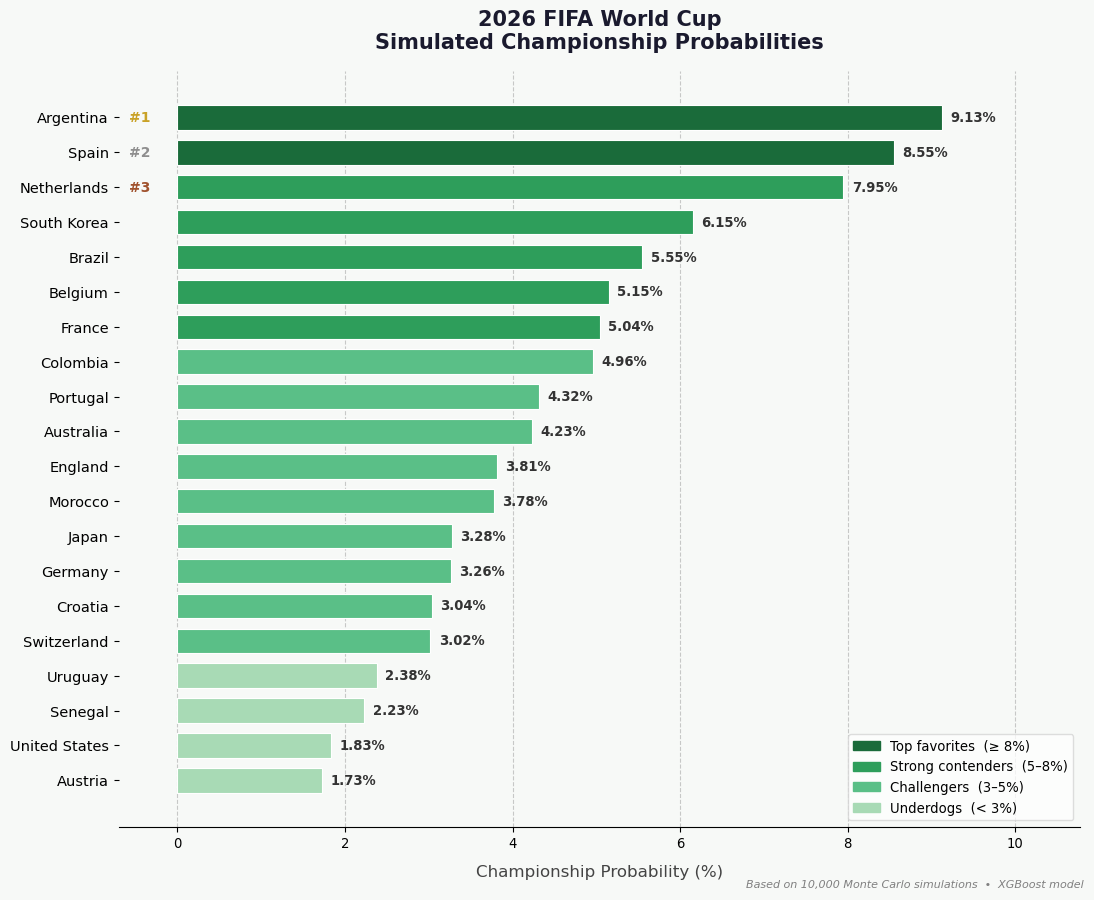

Saved → outputs/championship_probabilities.png


In [53]:

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

top20 = champ_df.head(20).copy()

# Color-code bars by tier
def get_color(prob):
    if prob >= 8:    return "#1a6b3a"   # dark green — top favorites
    elif prob >= 5:  return "#2e9e5b"   # medium green — strong contenders
    elif prob >= 3:  return "#5abf87"   # light green — challengers
    else:            return "#a8dab5"   # pale green — underdogs

colors = [get_color(p) for p in top20["probability_%"]]

fig, ax = plt.subplots(figsize=(11, 9))
fig.patch.set_facecolor("#f7f9f7")
ax.set_facecolor("#f7f9f7")

bars = ax.barh(top20["team"], top20["probability_%"],
               color=colors, edgecolor="white", linewidth=0.8, height=0.7)

# Value labels on the right of each bar
for bar, val in zip(bars, top20["probability_%"]):
    ax.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height() / 2,
            f"{val:.2f}%", va="center", ha="left", fontsize=9.5,
            fontweight="bold", color="#333333")

# Rank badges (#1, #2, #3) on the left
rank_colors = {"#1": "#c9a227", "#2": "#8e8e8e", "#3": "#a0522d"}
for idx, badge in enumerate(["#1", "#2", "#3"]):
    ax.text(-0.45, idx, badge, va="center", ha="center", fontsize=10,
            fontweight="bold", color=rank_colors[badge])

ax.set_xlabel("Championship Probability (%)", fontsize=12, labelpad=10, color="#444")
ax.set_title("2026 FIFA World Cup\nSimulated Championship Probabilities",
             fontsize=15, fontweight="bold", pad=16, color="#1a1a2e")
ax.set_xlim(-0.7, top20["probability_%"].max() * 1.18)
ax.invert_yaxis()

# Subtle grid
ax.xaxis.grid(True, linestyle="--", alpha=0.4, color="grey")
ax.set_axisbelow(True)
ax.spines[["top", "right", "left"]].set_visible(False)
ax.tick_params(axis="y", labelsize=10.5)
ax.tick_params(axis="x", labelsize=9.5)

# Legend
legend_handles = [
    mpatches.Patch(color="#1a6b3a", label="Top favorites  (≥ 8%)"),
    mpatches.Patch(color="#2e9e5b", label="Strong contenders  (5–8%)"),
    mpatches.Patch(color="#5abf87", label="Challengers  (3–5%)"),
    mpatches.Patch(color="#a8dab5", label="Underdogs  (< 3%)"),
]
ax.legend(handles=legend_handles, loc="lower right", fontsize=9.5,
          framealpha=0.75, edgecolor="lightgrey")

# Footnote
fig.text(0.99, 0.005, f"Based on {N_SIMS:,} Monte Carlo simulations  •  XGBoost model",
         ha="right", va="bottom", fontsize=8, color="grey", style="italic")

plt.tight_layout()
plt.savefig("../outputs/championship_probabilities.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → outputs/championship_probabilities.png")



---

## Phase 4 — Conclusion

### What we built
Phase 4 completed the full project pipeline by turning the XGBoost classifier from Phase 3 into a working **Monte Carlo tournament simulator**. Running 10,000 simulated 2026 FIFA World Cups, each one independently replicating the group stage (48 teams → 12 groups → round-robin), third-place qualification, and five rounds of knockouts, gives us a probabilistic view of who is most likely to lift the trophy.

### What the results say
**Argentina leads at 9.13%**, consistent with their #1 FIFA ranking and near-perfect recent form going into 2024. **Spain (8.55%)** and **Netherlands (7.95%)** round out the top 3, both with strong rankings and solid recent campaigns. Traditional powerhouses Brazil (5.55%), France (5.04%), Portugal (4.32%), England (3.81%), and Germany (3.26%) all appear in the top 15, which aligns with football expectations. **South Korea (6.15%)** appearing 4th is a notable result — their recent form heading into mid-2024 was exceptional (avg goal diff of +3.8 over their last 5 games), which the model weights significantly alongside their ranking of 23rd.

### Limitations to keep in mind
- **Data is capped at June 2024** — player injuries, managerial changes, or form swings between July 2024 and the actual 2026 tournament are not captured.
- The model was trained on **historical match outcomes** and does not incorporate squad depth, individual player quality, or draw mechanics like bracket seeding rules.
- The 2026 bracket structure used here is a **simplified approximation** — the actual FIFA bracket pairings differ from the round-robin cross-group pairing used here.
- With 48 teams and 10,000 simulations, championship probabilities are **inherently spread thin** — any single team winning more than ~10% is already a strong signal.

### What comes next
With the simulation confirmed working and results validated, Phase 4 is complete. The next steps for this project could include incorporating post-2024 match data, adding player-level features (e.g., Elo ratings or squad market value), or refining the bracket structure to match the official 2026 FIFA format.


---

## Appendix — Debugging Diagnostics

The following cells were used during development to verify that the model was producing sensible probabilities after each bug fix. They are preserved here for reference but are not part of the main analysis.

In [ ]:
# Diagnostic: raw model probabilities for clear mismatches
test_cases = [
    ("Brazil",    "Curaçao"),
    ("Argentina", "Jordan"),
    ("France",    "Haiti"),
    ("Germany",   "Iraq"),
    ("Spain",     "New Zealand"),
]

print(f"{'Matchup':35s}  rank_diff  pts_diff  P(home_win)  P(draw)  P(away_win)")
print("-" * 90)
for home, away in test_cases:
    h, a = team_profiles[home], team_profiles[away]
    feats = [[
        h["ranking"]  - a["ranking"],
        h["points"]   - a["points"],
        h["form_5"]   - a["form_5"],
        h["avg_gf"]   - a["avg_gf"],
        h["avg_ga"]   - a["avg_ga"],
        h["win_rate"] - a["win_rate"],
        1
    ]]
    probs = model.predict_proba(feats)[0]
    print(f"{home+' vs '+away:35s}  {feats[0][0]:9.0f}  {feats[0][1]:8.0f}  "
          f"{probs[2]:11.3f}  {probs[1]:7.3f}  {probs[0]:9.3f}")

# Also print all profiles sorted by ranking
print("\n\nAll 48 profiles sorted by ranking:")
sorted_profiles = sorted(team_profiles.items(), key=lambda x: x[1]["ranking"])
print(f"{'Team':25s} {'rank':>5} {'pts':>6} {'form5':>6} {'avg_gf':>6} {'avg_ga':>6} {'wr5':>5}")
for team, p in sorted_profiles:
    print(f"{team:25s} {p['ranking']:5.0f} {p['points']:6.0f} {p['form_5']:6.2f} {p['avg_gf']:6.2f} {p['avg_ga']:6.2f} {p['win_rate']:5.2f}")

In [ ]:
# Diagnostic: raw model probabilities for clear mismatches
test_cases = [
    ("Brazil",    "Curaçao"),
    ("Argentina", "Jordan"),
    ("France",    "Haiti"),
]
print(f"{'Matchup':35s}  rank_diff  pts_diff  P(hw)  P(draw)  P(aw)")
print("-" * 75)
for home, away in test_cases:
    h, a = team_profiles[home], team_profiles[away]
    feats = [[
        h["ranking"]  - a["ranking"],
        h["points"]   - a["points"],
        h["form_5"]   - a["form_5"],
        h["avg_gf"]   - a["avg_gf"],
        h["avg_ga"]   - a["avg_ga"],
        h["win_rate"] - a["win_rate"],
        1
    ]]
    probs = model.predict_proba(feats)[0]
    print(f"{home+' vs '+away:35s}  {feats[0][0]:9.0f}  {feats[0][1]:8.0f}  "
          f"{probs[2]:.3f}   {probs[1]:.3f}   {probs[0]:.3f}")

In [ ]:
# Print full feature vectors for suspicious matchups
print("Full feature breakdown — Argentina vs Jordan:")
h, a = team_profiles["Argentina"], team_profiles["Jordan"]
feats = [h["ranking"]-a["ranking"], h["points"]-a["points"],
         h["form_5"]-a["form_5"], h["avg_gf"]-a["avg_gf"],
         h["avg_ga"]-a["avg_ga"], h["win_rate"]-a["win_rate"], 1]
print(f"  Argentina profile: {h}")
print(f"  Jordan profile:    {team_profiles['Jordan']}")
print(f"  Features: rank_diff={feats[0]:.1f}, pts={feats[1]:.1f}, form={feats[2]:.2f}, "
      f"gf={feats[3]:.2f}, ga={feats[4]:.2f}, wr={feats[5]:.2f}")

print()
print("Full feature breakdown — France vs Haiti:")
h, a = team_profiles["France"], team_profiles["Haiti"]
feats2 = [h["ranking"]-a["ranking"], h["points"]-a["points"],
          h["form_5"]-a["form_5"], h["avg_gf"]-a["avg_gf"],
          h["avg_ga"]-a["avg_ga"], h["win_rate"]-a["win_rate"], 1]
print(f"  France profile: {h}")
print(f"  Haiti profile:  {team_profiles['Haiti']}")
print(f"  Features: rank_diff={feats2[0]:.1f}, pts={feats2[1]:.1f}, form={feats2[2]:.2f}, "
      f"gf={feats2[3]:.2f}, ga={feats2[4]:.2f}, wr={feats2[5]:.2f}")